In [1]:
from cooltrack.predictor import CoolTrackPredictor

oracle = CoolTrackPredictor(
    dat_filepath="../data/cooltrack_coefficients.dat", 
    age_data_path="../data/age_data"
)

planet_params = {
    'mass_Mj': 11.2, 
    'T_irr': 100.0, 
    'Met': 0.0, 
    'core': 10.0, 
    'f_sed_refractory': 4.0, 
    'f_sed_volatile': 4.0, 
    'kzz': 8.0
}

target_age = 150e6

# Tell the oracle to run 1000 Monte Carlo draws!
results = oracle.predict(target_planet=planet_params, target_age_yr=target_age, n_draws=100)

t_median = results['T_int']
t_err_minus = t_median - results.get('T_int_lower', t_median)
t_err_plus = results.get('T_int_upper', t_median) - t_median

print(f"Intrinsic Temp : {t_median:.2f} (+{t_err_plus:.2f} / -{t_err_minus:.2f}) K")

# The engine creates '_lower' (16th percentile) and '_upper' (84th percentile) keys for errors
r_median = results['Req_Rj']
r_err_minus = r_median - results['Req_Rj_lower']
r_err_plus = results['Req_Rj_upper'] - r_median

print(f"Radius         : {r_median:.3f} (+{r_err_plus:.3f} / -{r_err_minus:.3f}) R_J")

# It also does this for every photometric band in your grid!
if 'log_Keck/NIRC2.J' in results:
    j_median = results['log_Keck/NIRC2.J']
    j_err_minus = j_median - results['log_Keck/NIRC2.J_lower']
    j_err_plus = results['log_Keck/NIRC2.J_upper'] - j_median
    print(f"Keck J-Band    : {j_median:.3f} (+{j_err_plus:.3f} / -{j_err_minus:.3f}) dex")

2026-05-07 09:57:18,595 - INFO - Loaded initial condition interpolators from 4 files.


Intrinsic Temp : 755.94 (+165.97 / -139.29) K
Radius         : 1.218 (+1.465 / -0.698) R_J
Keck J-Band    : 4.119 (+0.216 / -0.197) dex


In [2]:
results

{'age_yr': 150000000.0,
 'T_int': 755.9436335970574,
 'S_physical': 67394.17795693275,
 'tau': 1508682566106.6045,
 'Req_Rj': 1.2179550764668328,
 'log_JWST/NIRCam.F070W': 0.8355298028920553,
 'log_JWST/NIRCam.F090W': 3.429497872656043,
 'log_JWST/NIRCam.F115W': 4.005368388113518,
 'log_JWST/NIRCam.F140M': 3.1607863542183496,
 'log_JWST/NIRCam.F150W': 3.861252549855667,
 'log_JWST/NIRCam.F182M': 3.362831390325181,
 'log_JWST/NIRCam.F200W': 3.4989919807212932,
 'log_JWST/NIRCam.F210M': 3.657088128187836,
 'log_JWST/NIRCam.F250M': 2.907333157483062,
 'log_JWST/NIRCam.F277W': 3.1066073365544096,
 'log_JWST/NIRCam.F300M': 3.2924810613994846,
 'log_JWST/NIRCam.F335M': 2.773806002966245,
 'log_JWST/NIRCam.F356W': 3.507943543459154,
 'log_JWST/NIRCam.F410M': 3.680096309894579,
 'log_JWST/NIRCam.F430M': 3.297861611040529,
 'log_JWST/NIRCam.F444W': 3.3588550590775483,
 'log_JWST/NIRCam.F460M': 2.705202746778916,
 'log_JWST/NIRCam.F480M': 2.9074370277753347,
 'log_JWST/MIRI.F560W': 3.00980095737

Booting up CoolTrack Oracle...


2026-05-07 09:57:23,095 - INFO - Loaded initial condition interpolators from 4 files.



Evaluating Integrated Flux stability across 20 trials per setting...
--------------------------------------------------------------------
n_draws    | Integrated Error (dex)    | Avg Time (ms)  
--------------------------------------------------------------------
5          | 0.4848 ± 0.1527 dex       | 140.73 ms
10         | 0.6142 ± 0.1690 dex       | 218.60 ms
25         | 0.7265 ± 0.1082 dex       | 401.66 ms
50         | 0.7299 ± 0.0815 dex       | 799.11 ms
100        | 0.7312 ± 0.0497 dex       | 1587.68 ms
250        | 0.7372 ± 0.0416 dex       | 3689.30 ms
500        | 0.7435 ± 0.0234 dex       | 8074.55 ms
1000       | 0.7439 ± 0.0176 dex       | 15827.22 ms


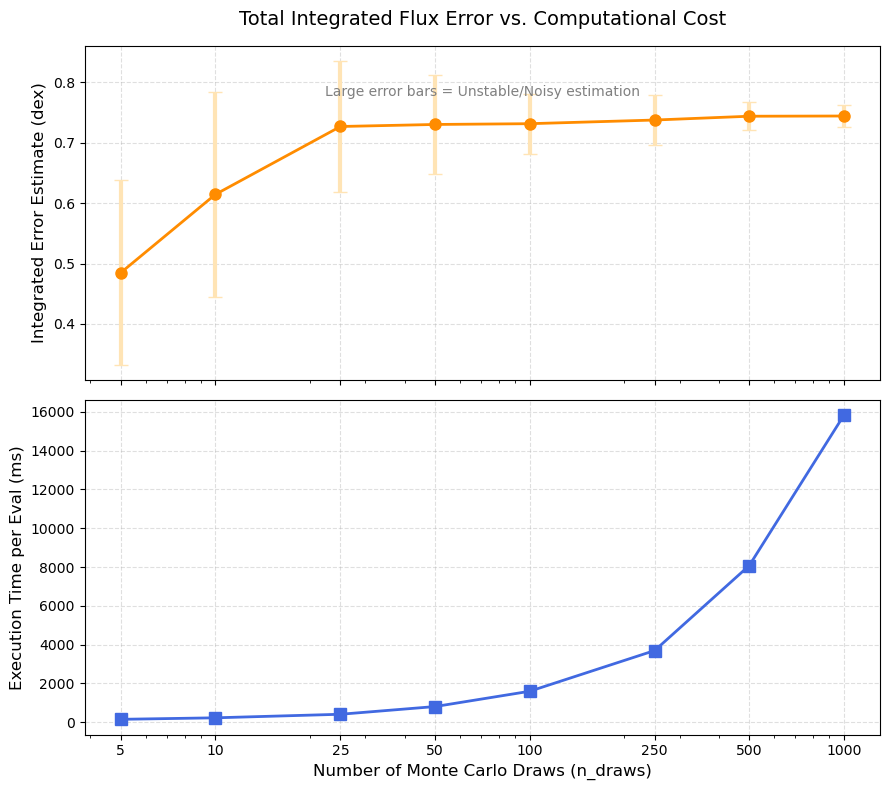

In [3]:
# --- RUN THIS ENTIRE BLOCK IN ONE JUPYTER CELL ---
%matplotlib inline

import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt

# Ensure Python can find the cooltrack modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor

# ==========================================
# 1. Setup the Oracle and Test Planet
# ==========================================
print("Booting up CoolTrack Oracle...")
oracle = CoolTrackPredictor(
    dat_filepath="../data/cooltrack_coefficients.dat", 
    age_data_path="../data/age_data"
)

# A standard test planet
planet_params = {
    'mass_Mj': 5.0, 
    'T_irr': 0.0, 
    'Met': 0.0, 
    'core': 10.0, 
    'f_sed_refractory': 6.0, 
    'f_sed_volatile': 6.0, 
    'kzz': 8.0
}

TARGET_AGE_YR = 150e6
OBSERVED_BAND = 'log_Keck/NIRC2.J'

# ==========================================
# 2. Run the Convergence Experiment
# ==========================================
draw_counts = [5, 10, 25, 50, 100, 250, 500, 1000]
n_trials = 20  

mean_errors = []
std_of_errors = []
avg_times_ms = []

print(f"\nEvaluating Integrated Flux stability across {n_trials} trials per setting...")
print("-" * 68)
print(f"{'n_draws':<10} | {'Integrated Error (dex)':<25} | {'Avg Time (ms)':<15}")
print("-" * 68)

for nd in draw_counts:
    trial_errors = []
    start_time = time.time()
    
    for _ in range(n_trials):
        results = oracle.predict(planet_params, TARGET_AGE_YR, n_draws=nd)
        
        # 1. Extract Surface Flux Bounds
        f_up = results.get(f"{OBSERVED_BAND}_upper", np.nan)
        f_low = results.get(f"{OBSERVED_BAND}_lower", np.nan)
        
        # 2. Extract Radius Bounds
        r_up = results.get("Req_Rj_upper", np.nan)
        r_low = results.get("Req_Rj_lower", np.nan)
        
        if not np.isnan(f_up) and not np.isnan(r_up):
            # Calculate surface flux error
            flux_err = (f_up - f_low) / 2.0
            
            # Convert linear radius bounds to log10 space
            log_r_up = np.log10(r_up)
            log_r_low = np.log10(r_low)
            
            # Calculate radius error and scale by 2 (because Area ~ R^2)
            log_rad_err = (log_r_up - log_r_low) / 2.0
            rad_contribution_err = 2.0 * log_rad_err
            
            # Combine independent errors in quadrature
            total_integrated_err = np.sqrt(flux_err**2 + rad_contribution_err**2)
            trial_errors.append(total_integrated_err)
        else:
            trial_errors.append(0.0)
            
    # Calculate execution time per run
    total_time = time.time() - start_time
    dt_ms = (total_time / n_trials) * 1000
    
    # Calculate statistics
    mean_err = np.mean(trial_errors)
    std_err = np.std(trial_errors) 
    
    mean_errors.append(mean_err)
    std_of_errors.append(std_err)
    avg_times_ms.append(dt_ms)
    
    print(f"{nd:<10} | {mean_err:.4f} ± {std_err:.4f} dex{' ':>6} | {dt_ms:.2f} ms")

# ==========================================
# 3. Plot the Results
# ==========================================
mean_errors = np.array(mean_errors)
std_of_errors = np.array(std_of_errors)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# --- Top Panel: Total Error Stability ---
ax1.errorbar(draw_counts, mean_errors, yerr=std_of_errors, fmt='-o', color='darkorange', 
             ecolor='moccasin', elinewidth=3, capsize=5, lw=2, markersize=8)
ax1.set_ylabel('Integrated Error Estimate (dex)', fontsize=12)
ax1.set_title('Total Integrated Flux Error vs. Computational Cost', fontsize=14, pad=15)
ax1.grid(True, alpha=0.4, linestyle='--')
ax1.text(0.5, 0.85, "Large error bars = Unstable/Noisy estimation", 
         transform=ax1.transAxes, fontsize=10, color='gray', ha='center')

# --- Bottom Panel: Computational Cost ---
ax2.plot(draw_counts, avg_times_ms, '-s', color='royalblue', lw=2, markersize=8)
ax2.set_ylabel('Execution Time per Eval (ms)', fontsize=12)
ax2.set_xlabel('Number of Monte Carlo Draws (n_draws)', fontsize=12)
ax2.set_xscale('log') 
ax2.set_xticks(draw_counts)
ax2.set_xticklabels(draw_counts)
ax2.grid(True, alpha=0.4, linestyle='--')

plt.tight_layout()
plt.show()

Booting up CoolTrack Oracle...


2026-05-07 10:10:00,193 - INFO - Loaded initial condition interpolators from 4 files.


Loaded 142 photometric bands from cooltrack.constants...

Running full integrated error survey (n_draws=250)...

--- 1-Sigma Total Integrated Error Matrix (dex) ---
                F070W  F090W  F115W  F140M  F150W  F182M  F200W  F210M  F250M  \
1 Mj (10 Myr)   0.743  0.631  0.608  0.597  0.690  0.583  0.585  0.602  0.582   
5 Mj (150 Myr)  0.836  0.757  0.748  0.739  0.781  0.745  0.759  0.776  0.758   
10 Mj (1 Gyr)   0.599  0.544  0.560  0.505  0.585  0.526  0.541  0.561  0.526   
15 Mj (5 Gyr)   0.466  0.398  0.389  0.359  0.448  0.380  0.383  0.416  0.373   

                F277W  ...    7_7    8_7    9_7      N   11_7  12_282  12_33  \
1 Mj (10 Myr)   0.586  ...  0.564  0.548  0.543  0.543  0.544   0.544  0.544   
5 Mj (150 Myr)  0.743  ...  0.723  0.712  0.707  0.707  0.707   0.708  0.707   
10 Mj (1 Gyr)   0.521  ...  0.486  0.480  0.474  0.473  0.474   0.473  0.474   
15 Mj (5 Gyr)   0.372  ...  0.331  0.315  0.306  0.306  0.307   0.307  0.306   

                   18     20

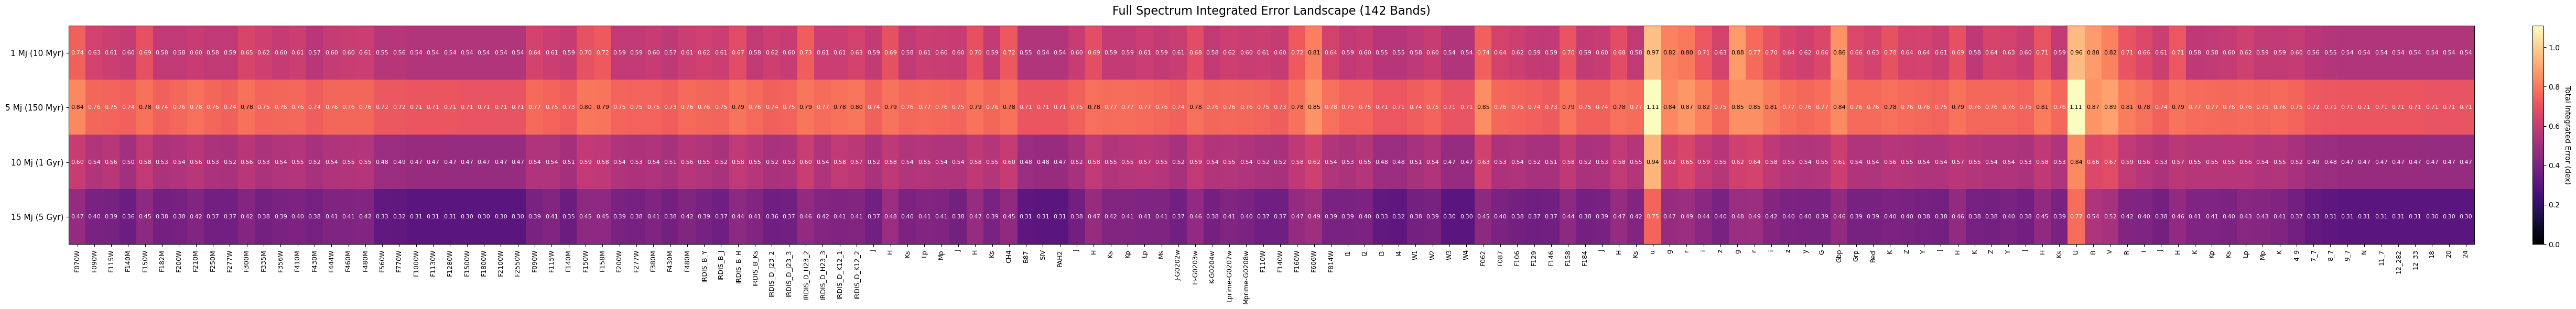

In [4]:
# --- RUN THIS ENTIRE BLOCK IN ONE JUPYTER CELL ---
%matplotlib inline

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure Python can find the cooltrack modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor
from cooltrack.constants import PHOTOMETRY_BANDS

# ==========================================
# 1. Setup the Oracle
# ==========================================
print("Booting up CoolTrack Oracle...")
oracle = CoolTrackPredictor(
    dat_filepath="../data/cooltrack_coefficients.dat", 
    age_data_path="../data/age_data"
)

base_params = {
    'T_irr': 0.0, 'Met': 0.0, 'core': 10.0, 'kzz': 8.0,
    'f_sed_refractory': 6.0, 'f_sed_volatile': 6.0
}

# The extreme states we want to test
test_planets = [
    {"name": "1 Mj (10 Myr)",   "mass": 1.0,  "age": 10e6},
    {"name": "5 Mj (150 Myr)",  "mass": 5.0,  "age": 150e6},
    {"name": "10 Mj (1 Gyr)",   "mass": 10.0, "age": 1e9},
    {"name": "15 Mj (5 Gyr)",   "mass": 15.0, "age": 5e9}
]

test_bands = PHOTOMETRY_BANDS
print(f"Loaded {len(test_bands)} photometric bands from cooltrack.constants...\n")

# ==========================================
# 2. Run the Massive Survey (Integrated Flux)
# ==========================================
# We use n_draws=250 as proven by our convergence test!
print("Running full integrated error survey (n_draws=250)...")
results_data = np.zeros((len(test_planets), len(test_bands)))

for i, test in enumerate(test_planets):
    planet = base_params.copy()
    planet['mass_Mj'] = test['mass']
    
    # Run the fully converged Monte Carlo
    res = oracle.predict(planet, test['age'], n_draws=250)
    
    # Extract the Radius error for this specific planet state
    r_up = res.get("Req_Rj_upper", np.nan)
    r_low = res.get("Req_Rj_lower", np.nan)
    
    # Calculate geometric radius error (Area scales as R^2, so 2 * log10(R))
    if not np.isnan(r_up) and not np.isnan(r_low) and r_up > 0 and r_low > 0:
        rad_err = 2.0 * ((np.log10(r_up) - np.log10(r_low)) / 2.0)
    else:
        rad_err = np.nan
        
    for j, band in enumerate(test_bands):
        # Extract the Surface Flux error for this band
        f_up = res.get(f"log_{band}_upper", np.nan)
        f_low = res.get(f"log_{band}_lower", np.nan)
        
        if not np.isnan(f_up) and not np.isnan(f_low) and not np.isnan(rad_err):
            flux_err = (f_up - f_low) / 2.0
            
            # Combine Flux and Radius errors in quadrature
            total_error_dex = np.sqrt(flux_err**2 + rad_err**2)
            results_data[i, j] = total_error_dex
        else:
            results_data[i, j] = np.nan

# ==========================================
# 3. Display & Plot Panoramic Results
# ==========================================
# Clean up band names for the display (remove instrument prefixes to save space)
clean_band_names = [b.split('.')[-1] if '.' in b else b for b in test_bands]

# Print DataFrame
df_results = pd.DataFrame(
    results_data, 
    columns=clean_band_names, 
    index=[p['name'] for p in test_planets]
)
print("\n--- 1-Sigma Total Integrated Error Matrix (dex) ---")
print(df_results.round(3))

# Plot a wide Heatmap
fig_width = max(12, len(test_bands) * 0.4)
fig, ax = plt.subplots(figsize=(fig_width, 6))

# We use the 'magma' colormap to clearly show error "hotspots"
cax = ax.imshow(results_data, cmap='magma', aspect='auto', vmin=0.0)

# Add colorbar
cbar = fig.colorbar(cax, pad=0.02)
cbar.set_label('Total Integrated Error (dex)', rotation=270, labelpad=15)

# Format axes
ax.set_xticks(np.arange(len(test_bands)))
ax.set_yticks(np.arange(len(test_planets)))
ax.set_xticklabels(clean_band_names, fontsize=9, rotation=90, ha='center')
ax.set_yticklabels([p['name'] for p in test_planets], fontsize=11)
ax.set_title(f"Full Spectrum Integrated Error Landscape ({len(test_bands)} Bands)", fontsize=16, pad=15)

# Annotate each cell with the exact numeric error
for i in range(len(test_planets)):
    for j in range(len(test_bands)):
        val = results_data[i, j]
        if not np.isnan(val):
            # Dynamic text color for readability
            color = "black" if val > (np.nanmax(results_data) * 0.7) else "white"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=8)

plt.tight_layout()
plt.show()

Booting up CoolTrack Oracle...


2026-05-07 10:25:19,549 - INFO - Loaded initial condition interpolators from 4 files.


Sweeping log-scaled INTEGRATED grid gaps for Keck/NIRC2.J at 150.0 Myr...
Log Gap -0.52 to -0.40 (Linear:  0.3 to  0.4 M_J) : 24.327 dex
Log Gap -0.40 to -0.28 (Linear:  0.4 to  0.5 M_J) : 10.142 dex
Log Gap -0.28 to -0.16 (Linear:  0.5 to  0.7 M_J) : 0.593 dex
Log Gap -0.16 to -0.04 (Linear:  0.7 to  0.9 M_J) : 0.508 dex
Log Gap -0.04 to 0.08 (Linear:  0.9 to  1.2 M_J) : 0.351 dex
Log Gap 0.08 to 0.21 (Linear:  1.2 to  1.6 M_J) : 0.575 dex
Log Gap 0.21 to 0.33 (Linear:  1.6 to  2.1 M_J) : 0.649 dex
Log Gap 0.33 to 0.45 (Linear:  2.1 to  2.8 M_J) : 0.618 dex
Log Gap 0.45 to 0.57 (Linear:  2.8 to  3.7 M_J) : 0.436 dex
Log Gap 0.57 to 0.69 (Linear:  3.7 to  4.9 M_J) : 0.299 dex
Log Gap 0.69 to 0.81 (Linear:  4.9 to  6.5 M_J) : 0.229 dex
Log Gap 0.81 to 0.93 (Linear:  6.5 to  8.6 M_J) : 0.176 dex
Log Gap 0.93 to 1.05 (Linear:  8.6 to 11.3 M_J) : 0.122 dex
Log Gap 1.05 to 1.18 (Linear: 11.3 to 15.0 M_J) : 0.143 dex

   INTEGRATED LOG-SCALED DISTANCE PENALTY RESULTS   
Average stable gap pe

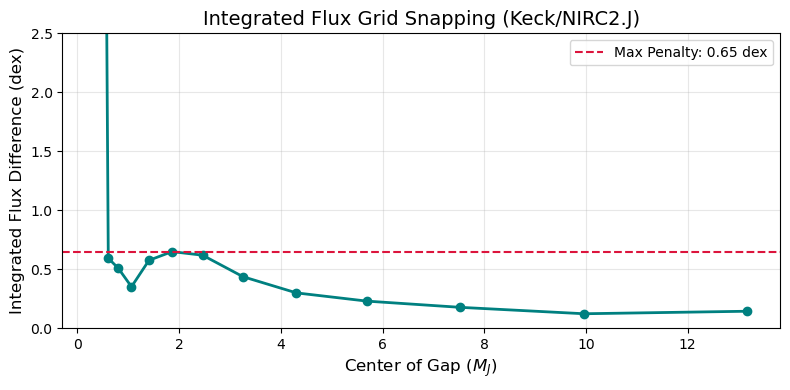

In [5]:
# --- RUN THIS ENTIRE BLOCK IN ONE JUPYTER CELL ---
%matplotlib inline

import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ensure Python can find the cooltrack modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor

# ==========================================
# 1. Setup the Oracle
# ==========================================
print("Booting up CoolTrack Oracle...")
oracle = CoolTrackPredictor(
    dat_filepath="../data/cooltrack_coefficients.dat", 
    age_data_path="../data/age_data"
)

TARGET_AGE_YR = 150e6
OBSERVED_BAND = 'Keck/NIRC2.J'  

base_params = {
    'T_irr': 0.0, 'Met': 0.0, 'core': 10.0, 'kzz': 8.0,
    'f_sed_refractory': 6.0, 'f_sed_volatile': 6.0
}

# ==========================================
# 2. Run the Log-Scaled Calibration Sweep
# ==========================================
print(f"Sweeping log-scaled INTEGRATED grid gaps for {OBSERVED_BAND} at {TARGET_AGE_YR/1e6} Myr...")

num_points = 20
log_masses = np.linspace(np.log10(0.3), np.log10(50.0), num_points)

flux_differences = []
gap_centers_linear = [] # For plotting

for i in range(len(log_masses) - 1):
    # 1. Evaluate the lower edge of the log-gap
    mass_lower = 10**log_masses[i]
    p_lower = base_params.copy()
    p_lower['mass_Mj'] = mass_lower
    res_lower = oracle.predict(p_lower, TARGET_AGE_YR, n_draws=0)
    
    surf_flux_lower = res_lower.get(f"log_{OBSERVED_BAND}", np.nan)
    rad_lower = res_lower.get("Req_Rj", np.nan)
    
    # 2. Evaluate the upper edge of the log-gap
    mass_upper = 10**log_masses[i+1]
    p_upper = base_params.copy()
    p_upper['mass_Mj'] = mass_upper
    res_upper = oracle.predict(p_upper, TARGET_AGE_YR, n_draws=0)
    
    surf_flux_upper = res_upper.get(f"log_{OBSERVED_BAND}", np.nan)
    rad_upper = res_upper.get("Req_Rj", np.nan)
    
    # 3. Calculate the INTEGRATED absolute difference
    if not np.isnan(surf_flux_lower) and not np.isnan(surf_flux_upper) and rad_lower > 0 and rad_upper > 0:
        
        # Total Integrated Flux = Surface Flux + 2 * log10(Radius)
        int_flux_lower = surf_flux_lower + (2.0 * np.log10(rad_lower))
        int_flux_upper = surf_flux_upper + (2.0 * np.log10(rad_upper))
        
        delta = abs(int_flux_upper - int_flux_lower)
        
        flux_differences.append(delta)
        gap_centers_linear.append((mass_lower + mass_upper) / 2.0)
        print(f"Log Gap {log_masses[i]:.2f} to {log_masses[i+1]:.2f} (Linear: {mass_lower:>4.1f} to {mass_upper:>4.1f} M_J) : {delta:.3f} dex")
    else:
        flux_differences.append(np.nan)
        gap_centers_linear.append((mass_lower + mass_upper) / 2.0)
        print(f"Log Gap {log_masses[i]:.2f} to {log_masses[i+1]:.2f} : NaN (Out of bounds)")

# ==========================================
# 3. Results & Recommendation
# ==========================================
flux_differences = np.array(flux_differences)
valid_deltas = flux_differences[~np.isnan(flux_differences)]

# Filter out massive physical "cliffs" (e.g. dropping off the grid below 0.5 M_J)
stable_deltas = valid_deltas[valid_deltas < 2.0]

if len(stable_deltas) > 0:
    max_penalty = np.max(stable_deltas)
    mean_penalty = np.mean(stable_deltas)
    
    print("\n" + "="*55)
    print("   INTEGRATED LOG-SCALED DISTANCE PENALTY RESULTS   ")
    print("="*55)
    print(f"Average stable gap penalty : {mean_penalty:.3f} dex")
    print(f"Maximum stable gap penalty : {max_penalty:.3f} dex")
    print("-" * 55)
    print(f"RECOMMENDATION: Set MAX_GAP_ERROR = {max_penalty:.2f}")
    print("="*55)
    
    # Plotting against the linear mass center for readability
    plt.figure(figsize=(8, 4))
    plt.plot(gap_centers_linear, flux_differences, marker='o', linestyle='-', color='teal', lw=2)
    plt.axhline(max_penalty, color='crimson', linestyle='--', label=f'Max Penalty: {max_penalty:.2f} dex')
    
    plt.title(f'Integrated Flux Grid Snapping ({OBSERVED_BAND})', fontsize=14)
    plt.xlabel('Center of Gap ($M_J$)', fontsize=12)
    plt.ylabel('Integrated Flux Difference (dex)', fontsize=12)
    
    # Safely set Y-limits so the plot isn't ruined by a 24.4 dex physics cliff
    plt.ylim(0, min(np.nanmax(flux_differences) + 0.1, 2.5)) 
    
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Could not evaluate stable grid gaps. Check your parameters.")

Booting up CoolTrack Oracle...


2026-05-07 10:40:37,313 - INFO - Loaded initial condition interpolators from 4 files.



[Phase 1 & 2] Profiling Integrated Errors at Median Age (150 Myr)...
--> Profilers Complete (23.0s). Ready for 2D MCMC.

[Phase 3] Launching Integrated 2D MCMC...


100%|██████████| 1500/1500 [02:37<00:00,  9.52it/s]



     FINAL INTEGRATED RETRIEVAL RESULTS    
   Mass ($M_J$): 2.84 (+3.26 / -1.27)
      Age (Myr): 127.80 (+55.08 / -59.48)


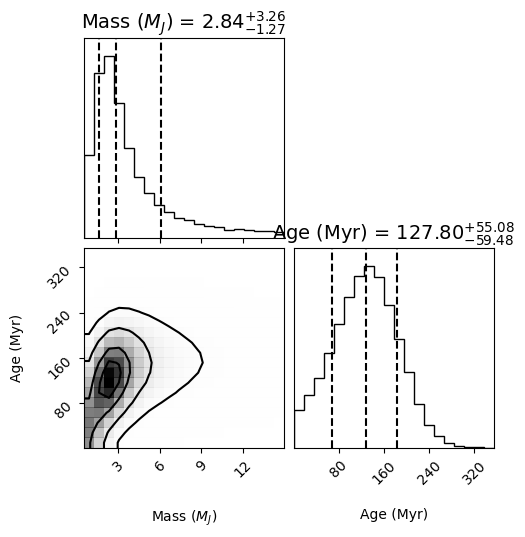

In [10]:
# --- RUN THIS ENTIRE BLOCK IN ONE JUPYTER CELL ---
%matplotlib inline

import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import corner
import emcee
from multiprocessing import Pool, cpu_count

# ==========================================
# 0. SYSTEM CRITICAL OVERRIDES
# ==========================================
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor

# ==========================================
# 1. SETUP: ORACLE & OBSERVATIONS
# ==========================================
print("Booting up CoolTrack Oracle...")
oracle = CoolTrackPredictor(
    dat_filepath="../data/cooltrack_coefficients.dat", 
    age_data_path="../data/age_data"
)

# --- OBSERVED TARGET & SYSTEM AGE ---
OBS_AGE_MEAN_YR = 150e6
OBS_AGE_ERR_YR  = 50e6  

OBSERVED_BAND = 'Keck/NIRC2.J'  
OBSERVED_FLUX = 4.0  
FLUX_ERROR = 0.05               

MIN_MASS = 0.5
MAX_MASS = 15.0

FIXED_PARAMS = {
    'T_irr': 0.0, 'Met': 0.0, 'core': 10.0, 'kzz': 8.0,
    'f_sed_refractory': 6.0, 'f_sed_volatile': 6.0
}

# ==========================================
# 2. PRE-FLIGHT PROFILERS (Evaluated at Median Age)
# ==========================================
print(f"\n[Phase 1 & 2] Profiling Integrated Errors at Median Age ({OBS_AGE_MEAN_YR/1e6:.0f} Myr)...")
t0 = time.time()

# 2A. INTEGRATED Grid Gap Calibrator
num_calib_points = 15
log_masses_calib = np.linspace(np.log10(MIN_MASS), np.log10(MAX_MASS), num_calib_points)
gap_centers, gap_errors = [], []

for i in range(len(log_masses_calib) - 1):
    mass_lower = 10**log_masses_calib[i]
    mass_upper = 10**log_masses_calib[i+1]
    
    # Evaluate Lower
    res_lower = oracle.predict({**FIXED_PARAMS, 'mass_Mj': mass_lower}, OBS_AGE_MEAN_YR, n_draws=0)
    f_low = res_lower.get(f"log_{OBSERVED_BAND}", np.nan)
    r_low = res_lower.get("Req_Rj", np.nan)
    
    # Evaluate Upper
    res_upper = oracle.predict({**FIXED_PARAMS, 'mass_Mj': mass_upper}, OBS_AGE_MEAN_YR, n_draws=0)
    f_high = res_upper.get(f"log_{OBSERVED_BAND}", np.nan)
    r_high = res_upper.get("Req_Rj", np.nan)
    
    # Calculate Integrated Delta (4*pi cancels mathematically, but included for absolute consistency)
    if not np.isnan(f_low) and not np.isnan(f_high) and r_low > 0 and r_high > 0:
        int_f_low = f_low + 2.0 * np.log10(r_low) + np.log10(4 * np.pi)
        int_f_high = f_high + 2.0 * np.log10(r_high) + np.log10(4 * np.pi)
        delta = min(abs(int_f_high - int_f_low), 2.0) # Cap physical cliffs
        
        gap_centers.append(10**((log_masses_calib[i] + log_masses_calib[i+1]) / 2.0))
        gap_errors.append(delta)

gap_centers, gap_errors = np.array(gap_centers), np.array(gap_errors)

# 2B. INTEGRATED B-Spline Calibrator (Using Converged n_draws=250)
profile_masses = np.linspace(MIN_MASS, MAX_MASS, 6)
profile_errors = []

for pm in profile_masses:
    res = oracle.predict({**FIXED_PARAMS, 'mass_Mj': pm}, OBS_AGE_MEAN_YR, n_draws=250)
    
    f_up = res.get(f"log_{OBSERVED_BAND}_upper", np.nan)
    f_low = res.get(f"log_{OBSERVED_BAND}_lower", np.nan)
    r_up = res.get("Req_Rj_upper", np.nan)
    r_low = res.get("Req_Rj_lower", np.nan)
    
    # 4*pi vanishes from variance calculation
    if not np.isnan(f_up) and not np.isnan(r_up) and r_up > 0 and r_low > 0:
        flux_err = (f_up - f_low) / 2.0
        rad_err = 2.0 * ((np.log10(r_up) - np.log10(r_low)) / 2.0)
        profile_errors.append(np.sqrt(flux_err**2 + rad_err**2))
    else:
        profile_errors.append(0.80) # Safe fallback based on convergence data

profile_errors = np.array(profile_errors)
print(f"--> Profilers Complete ({time.time()-t0:.1f}s). Ready for 2D MCMC.")

# ==========================================
# 3. 2D BAYESIAN MATH (MASS + AGE)
# ==========================================
def log_prior(theta):
    log_mass, log_age_yr = theta
    
    if not (np.log10(MIN_MASS) <= log_mass <= np.log10(MAX_MASS)):
        return -np.inf  
    if not (6.0 <= log_age_yr <= 10.0):
        return -np.inf
        
    linear_age = 10**log_age_yr
    return -0.5 * ((linear_age - OBS_AGE_MEAN_YR) / OBS_AGE_ERR_YR)**2

def log_likelihood(theta):
    log_mass, log_age_yr = theta
    linear_mass = 10**log_mass
    linear_age = 10**log_age_yr
    
    planet = FIXED_PARAMS.copy()
    planet['mass_Mj'] = linear_mass  
    
    try:
        results = oracle.predict(planet, linear_age, n_draws=0)
        
        # EXTRACT SURFACE FLUX AND RADIUS
        surf_flux = results.get(f"log_{OBSERVED_BAND}", np.nan)
        radius = results.get("Req_Rj", np.nan)
        
        if np.isnan(surf_flux) or np.isnan(radius) or radius <= 0:
            return -np.inf
            
        # ---> THE GEOMETRIC INTEGRATION (CORRECTED) <---
        integrated_model_flux = surf_flux + 2.0 * np.log10(radius) + np.log10(4 * np.pi)
        
        # Error 1: Observation
        obs_var = FLUX_ERROR**2
        
        # Error 2: Integrated B-Spline Error
        dynamic_bspline_err = np.interp(linear_mass, profile_masses, profile_errors)
        bspline_var = dynamic_bspline_err**2
        
        # Error 3: Integrated Local Grid Penalty
        local_max_gap_error = np.interp(linear_mass, gap_centers, gap_errors)
        fractional_distance = min(results['snap_distance'] / 0.5, 1.0)
        grid_err = local_max_gap_error * fractional_distance
        grid_var = grid_err**2
        
        # Total Variance
        total_variance = obs_var + bspline_var + grid_var
        
        # Evaluate Residual against the Integrated Flux
        residual = integrated_model_flux - OBSERVED_FLUX
        
        return -0.5 * ((residual**2 / total_variance) + np.log(2 * np.pi * total_variance))
        
    except Exception:
        return -np.inf

def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

# ==========================================
# 4. RUN PARALLEL 2D MCMC
# ==========================================
print(f"\n[Phase 3] Launching Integrated 2D MCMC...")
num_cores = max(1, cpu_count() - 1) 

ndim = 2         
# Ensure we have enough walkers for emcee (must be even and >= 2*ndim)
nwalkers = max(16, num_cores * 2)    
nsteps = 1500    

initial_guess = np.array([np.log10(5.0), np.log10(OBS_AGE_MEAN_YR)]) 
pos = initial_guess + 1e-4 * np.random.randn(nwalkers, ndim)

with Pool(num_cores) as pool:
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, pool=pool)
    sampler.run_mcmc(pos, nsteps, progress=True)

# ==========================================
# 5. POST-PROCESSING & PLOTTING
# ==========================================
burnin = int(0.2 * nsteps)
log_samples = sampler.get_chain(discard=burnin, flat=True)

linear_samples = np.zeros_like(log_samples)
linear_samples[:, 0] = 10**log_samples[:, 0]          
linear_samples[:, 1] = 10**log_samples[:, 1] / 1e6    

labels = ["Mass ($M_J$)", "Age (Myr)"]

print("\n" + "="*40)
print("     FINAL INTEGRATED RETRIEVAL RESULTS    ")
print("="*40)
for i in range(ndim):
    mcmc = np.percentile(linear_samples[:, i], [16, 50, 84])
    q = np.diff(mcmc)
    print(f"{labels[i]:>15}: {mcmc[1]:.2f} (+{q[1]:.2f} / -{q[0]:.2f})")
print("="*40)

fig = corner.corner(
    linear_samples, 
    labels=labels, 
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True, 
    title_kwargs={"fontsize": 14},
    smooth=1.0,
    plot_contours=True,
    plot_datapoints=False
)

plt.show()

Booting up CoolTrack Oracle...


2026-05-08 14:12:54,665 - INFO - Loaded initial condition interpolators from 4 files.


Evaluating 8 evolutionary tracks (Integrated Flux)...


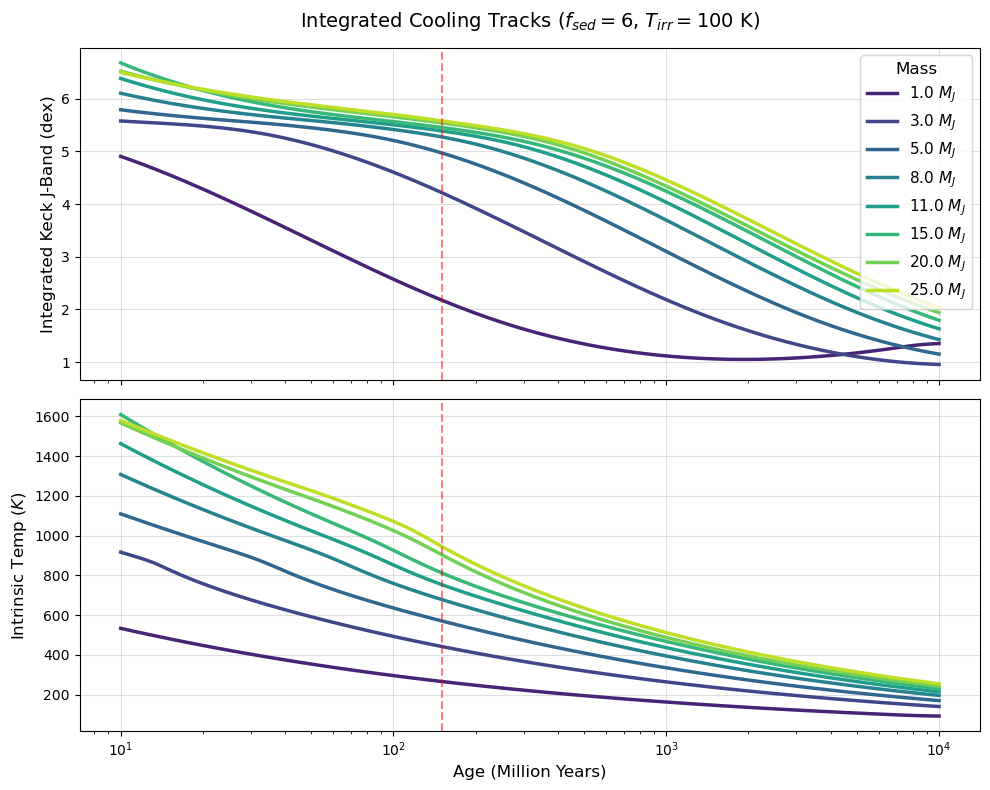

In [1]:
# --- RUN THIS ENTIRE BLOCK IN ONE JUPYTER CELL ---
%matplotlib inline

import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ensure Python can find the cooltrack modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor

# ==========================================
# 1. Setup the Oracle
# ==========================================
DAT_FILEPATH = "../data/cooltrack_coefficients.dat"
AGE_DATA_PATH = "../data/age_data"

print("Booting up CoolTrack Oracle...")
oracle = CoolTrackPredictor(dat_filepath=DAT_FILEPATH, age_data_path=AGE_DATA_PATH)

# ==========================================
# 2. Define the Target Grid
# ==========================================
# List of masses you want to overplot
masses_to_plot = [1.0, 3.0, 5.0, 8.0, 11.0, 15.0, 20.0, 25.0]

# Fixed parameters for all planets
base_params = {
    'T_irr': 100.0, 
    'Met': 0.0, 
    'core': 10.0, 
    'f_sed_refractory': 6.0, 
    'f_sed_volatile': 6.0, 
    'kzz': 8.0
}

# Create an array of 100 ages spaced logarithmically from 10 Myr to 10 Gyr
ages_yr = np.logspace(7, 10, 100)

# ==========================================
# 3. Evaluate & Plot the Results
# ==========================================
# Create a 2-panel plot (Photometry on top, Temperature on bottom)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Generate a nice color gradient based on the number of masses we are plotting
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(masses_to_plot)))

print(f"Evaluating {len(masses_to_plot)} evolutionary tracks (Integrated Flux)...")

for i, target_mass in enumerate(masses_to_plot):
    planet_params = base_params.copy()
    planet_params['mass_Mj'] = target_mass
    
    j_band_integrated = []
    t_int = []
    
    # Evaluate the track across all ages
    for age in ages_yr:
        # Use n_draws=0 for lightning-fast median predictions
        results = oracle.predict(target_planet=planet_params, target_age_yr=age, n_draws=0)
        
        # Pull Surface Flux and Radius
        surf_flux = results.get('log_Keck/NIRC2.J', np.nan)
        radius = results.get('Req_Rj', np.nan)
        
        # Calculate Total Integrated Flux
        if not np.isnan(surf_flux) and not np.isnan(radius) and radius > 0:
            integrated_flux = surf_flux + 2.0 * np.log10(radius) + np.log10(4 * np.pi)
            j_band_integrated.append(integrated_flux)
        else:
            j_band_integrated.append(np.nan)
            
        t_int.append(results.get('T_int', np.nan))
        
    # Plot this mass on the top panel (Photometry)
    ax1.plot(ages_yr / 1e6, j_band_integrated, label=f"{target_mass} $M_J$", color=colors[i], lw=2.5)
    
    # Plot this mass on the bottom panel (Temperature)
    ax2.plot(ages_yr / 1e6, t_int, color=colors[i], lw=2.5)

# --- Format Top Panel (Photometry) ---
ax1.set_ylabel('Integrated Keck J-Band (dex)', fontsize=12)
ax1.set_title(f'Integrated Cooling Tracks ($f_{{sed}}=6$, $T_{{irr}}=100$ K)', fontsize=14, pad=15)
ax1.legend(loc='upper right', fontsize=11, title="Mass", title_fontsize=12)
ax1.grid(True, alpha=0.4)

# Add vertical line for your target age
ax1.axvline(x=150, color='red', linestyle='--', alpha=0.5, label='150 Myr')

# --- Format Bottom Panel (Temperature) ---
ax2.set_xlabel('Age (Million Years)', fontsize=12)
ax2.set_ylabel('Intrinsic Temp ($K$)', fontsize=12)
ax2.set_xscale('log') 
ax2.grid(True, alpha=0.4)

ax2.axvline(x=150, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Booting up CoolTrack Oracle...


2026-05-07 11:00:47,032 - INFO - Loaded initial condition interpolators from 4 files.


Querying Oracle to map the 2D parameter space...
Fitting Inverse Spline: (Integrated Flux, Age) -> Mass...
--> Surface mapped in 146.42 seconds!

Running 10,000-draw Input Monte Carlo...
--> Extraction complete in 0.276 seconds! (8.4% out-of-bounds draws dropped)

      INVERSE MONTE CARLO MASS ESTIMATE      
Combined Input Flux Error: +/- 0.986 dex
Retrieved Mass: 2.47 M_J (+1.96 / -0.88)


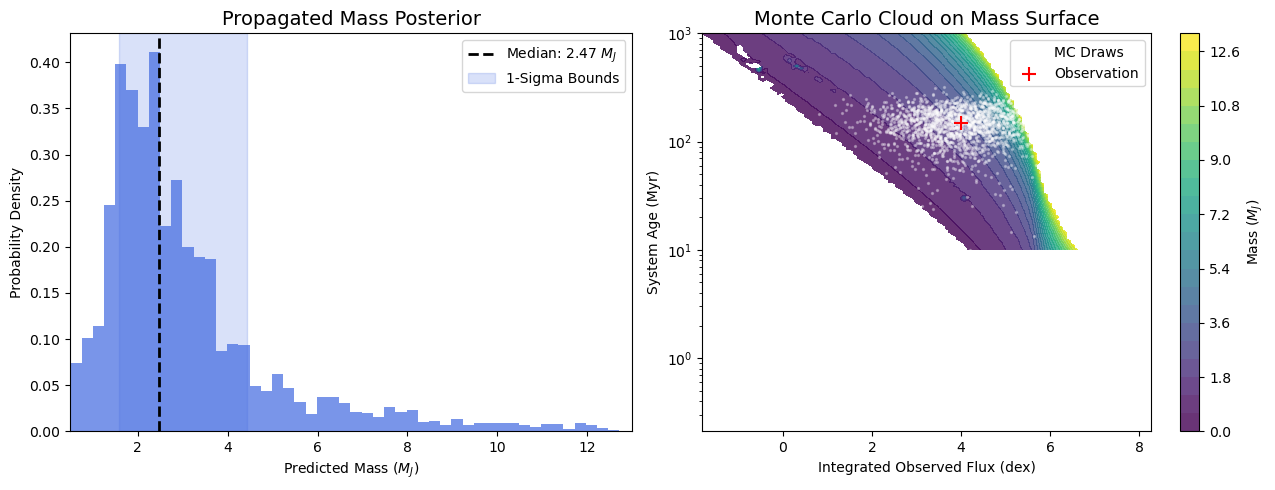

In [15]:
# --- RUN THIS ENTIRE BLOCK IN ONE JUPYTER CELL ---
%matplotlib inline

import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CloughTocher2DInterpolator

# Ensure Python can find the cooltrack modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor

# ==========================================
# 1. SETUP: ORACLE & TARGET
# ==========================================
print("Booting up CoolTrack Oracle...")
oracle = CoolTrackPredictor(
    dat_filepath="../data/cooltrack_coefficients.dat", 
    age_data_path="../data/age_data"
)

OBSERVED_BAND = 'Keck/NIRC2.J'  

# --- YOUR TARGET OBSERVATION & ERRORS ---
TARGET_AGE_YR = 150e6
TARGET_AGE_ERR = 50e6  

TARGET_FLUX = 4.0  
INSTRUMENT_FLUX_ERR = 0.05

MAX_BSPLINE_ERR = 0.74  
MAX_GRID_GAP_ERR = 0.65 

TOTAL_FLUX_ERR = np.sqrt(INSTRUMENT_FLUX_ERR**2 + MAX_BSPLINE_ERR**2 + MAX_GRID_GAP_ERR**2)

# --- NEW: EXPLICIT GRID BOUNDARIES ---
MIN_MASS = 0.5
MAX_MASS = 13.0

FIXED_PARAMS = {
    'T_irr': 0.0, 'Met': 0.0, 'core': 10.0, 'kzz': 8.0,
    'f_sed_refractory': 6.0, 'f_sed_volatile': 6.0
}

# ==========================================
# 2. GENERATE THE DENSE FORWARD GRID
# ==========================================
print("Querying Oracle to map the 2D parameter space...")
t0 = time.time()

mass_range = np.logspace(np.log10(MIN_MASS), np.log10(MAX_MASS), 100)
age_range_yr = np.logspace(np.log10(10e6), np.log10(1e9), 100) 

fluxes, ages, masses = [], [], []

for mass in mass_range:
    planet = FIXED_PARAMS.copy()
    planet['mass_Mj'] = mass
    for age in age_range_yr:
        res = oracle.predict(planet, age, n_draws=0)
        
        surf_flux = res.get(f"log_{OBSERVED_BAND}", np.nan)
        radius = res.get("Req_Rj", np.nan)
        
        if not np.isnan(surf_flux) and not np.isnan(radius) and radius > 0:
            integrated_flux = surf_flux + 2.0 * np.log10(radius) + np.log10(4 * np.pi)
            fluxes.append(integrated_flux)
            ages.append(np.log10(age)) 
            masses.append(mass)

fluxes = np.array(fluxes)
ages = np.array(ages)
masses = np.array(masses)

# ==========================================
# 3. BUILD THE INVERSE SPLINE
# ==========================================
print(f"Fitting Inverse Spline: (Integrated Flux, Age) -> Mass...")
points = np.column_stack((fluxes, ages))
inverse_spline = CloughTocher2DInterpolator(points, masses)
print(f"--> Surface mapped in {time.time() - t0:.2f} seconds!")

# ==========================================
# 4. MONTE CARLO ERROR PROPAGATION
# ==========================================
print("\nRunning 10,000-draw Input Monte Carlo...")
t1 = time.time()

np.random.seed(42)
mc_fluxes = np.random.normal(TARGET_FLUX, TOTAL_FLUX_ERR, 10000)
mc_ages_yr = np.random.normal(TARGET_AGE_YR, TARGET_AGE_ERR, 10000)

valid_mask = mc_ages_yr > 0
mc_fluxes = mc_fluxes[valid_mask]
mc_ages_yr = mc_ages_yr[valid_mask]
mc_log_ages = np.log10(mc_ages_yr)

predicted_masses = inverse_spline(mc_fluxes, mc_log_ages)

# 4D. Clean NaNs and ENFORCE PHYSICAL GRID LIMITS
valid_predictions = predicted_masses[~np.isnan(predicted_masses)]

# ---> THE FIX: Drop any points where the cubic spline overshot reality <---
physical_bounds_mask = (valid_predictions >= MIN_MASS) & (valid_predictions <= MAX_MASS)
valid_predictions = valid_predictions[physical_bounds_mask]

dropped_pct = (1.0 - (len(valid_predictions) / 10000)) * 100

if len(valid_predictions) == 0:
    print("ERROR: All draws fell outside the physical model grid bounds.")
else:
    p16, p50, p84 = np.percentile(valid_predictions, [16, 50, 84])
    print(f"--> Extraction complete in {time.time() - t1:.3f} seconds! ({dropped_pct:.1f}% out-of-bounds draws dropped)")
    
    print("\n" + "="*45)
    print("      INVERSE MONTE CARLO MASS ESTIMATE      ")
    print("="*45)
    print(f"Combined Input Flux Error: +/- {TOTAL_FLUX_ERR:.3f} dex")
    print(f"Retrieved Mass: {p50:.2f} M_J (+{p84-p50:.2f} / -{p50-p16:.2f})")
    print("="*45)

# ==========================================
# 5. VISUALIZATION
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: The Interpolated Mass Posterior
ax1.hist(valid_predictions, bins=50, color='royalblue', alpha=0.7, density=True)
ax1.axvline(p50, color='k', linestyle='--', lw=2, label=f'Median: {p50:.2f} $M_J$')
ax1.axvspan(p16, p84, color='royalblue', alpha=0.2, label='1-Sigma Bounds')
ax1.set_title("Propagated Mass Posterior", fontsize=14)
ax1.set_xlabel("Predicted Mass ($M_J$)")
ax1.set_ylabel("Probability Density")
ax1.set_xlim(MIN_MASS, MAX_MASS) 
ax1.legend()

# Plot 2: The Monte Carlo Draw Cloud on the Inverse Surface
plot_f = np.linspace(fluxes.min(), fluxes.max(), 100)
plot_a = np.linspace(ages.min(), ages.max(), 100)
F_grid, A_grid = np.meshgrid(plot_f, plot_a)
M_grid = inverse_spline(F_grid, A_grid)

# ---> THE FIX: Mask unphysical polynomial overshoots in the contour grid <---
M_grid[(M_grid < MIN_MASS) | (M_grid > MAX_MASS)] = np.nan

# We also add vmin and vmax to strictly lock the colorbar
cmap = plt.cm.viridis
cmap.set_bad('white', 0.) # Renders the NaN areas as transparent/white
c = ax2.contourf(F_grid, 10**A_grid / 1e6, M_grid, levels=20, cmap=cmap, alpha=0.8, vmin=MIN_MASS, vmax=MAX_MASS)
cbar = plt.colorbar(c, ax=ax2)
cbar.set_label('Mass ($M_J$)')

subset = min(2000, len(mc_fluxes))
ax2.scatter(mc_fluxes[:subset], mc_ages_yr[:subset] / 1e6, color='white', s=2, alpha=0.3, label='MC Draws')
ax2.scatter(TARGET_FLUX, TARGET_AGE_YR / 1e6, color='red', marker='+', s=100, label='Observation')

ax2.set_title(f"Monte Carlo Cloud on Mass Surface", fontsize=14)
ax2.set_xlabel(f"Integrated Observed Flux (dex)")
ax2.set_ylabel("System Age (Myr)")
ax2.set_yscale('log')
ax2.legend()

plt.tight_layout()
plt.show()

Booting up CoolTrack Oracle...


2026-05-07 13:50:38,262 - INFO - Loaded initial condition interpolators from 4 files.



[Phase 1] Auto-Calibrating Local Integrated Error Profiles...
--> Local Error Profiles mapped in 23.2s.

[Phase 2] Building Integrated Inverse Spline Surface...
--> Surface mapped in 147.41 seconds.

[Phase 3] Running Two-Step Localized Monte Carlo (10,000 draws)...
--> Extraction complete in 0.145 seconds! (1.3% out-of-bounds)

   FULLY LOCALIZED INVERSE MASS ESTIMATE   
Retrieved Mass: 1.68 M_J (+0.74 / -0.70)


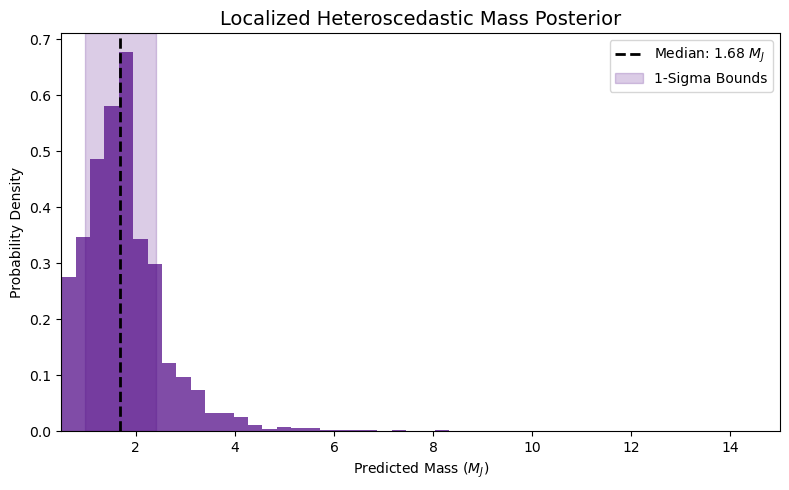

In [30]:
# --- RUN THIS ENTIRE BLOCK IN ONE JUPYTER CELL ---
%matplotlib inline

import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CloughTocher2DInterpolator

# Ensure Python can find the cooltrack modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor

# ==========================================
# 1. SETUP: ORACLE & TARGET
# ==========================================
print("Booting up CoolTrack Oracle...")
oracle = CoolTrackPredictor("../data/cooltrack_coefficients.dat", "../data/age_data")
OBSERVED_BAND = 'Keck/NIRC2.J'  

# Your Target Observation (Make sure this is your Integrated Flux!)
TARGET_FLUX = 4.0
INSTRUMENT_FLUX_ERR = 0.05  # Pure instrument/photon noise

TARGET_AGE_YR = 150e6
TARGET_AGE_ERR = 50e6  

MIN_MASS, MAX_MASS = 0.5, 15.0

FIXED_PARAMS = {
    'T_irr': 0.0, 'Met': 0.0, 'core': 10.0, 'kzz': 8.0,
    'f_sed_refractory': 6.0, 'f_sed_volatile': 6.0
}

# ==========================================
# 2. CALIBRATE LOCAL ERRORS (Grid & B-Spline)
# ==========================================
print("\n[Phase 1] Auto-Calibrating Local Integrated Error Profiles...")
t0 = time.time()

# 2A. INTEGRATED Grid Gap Calibrator
log_masses_calib = np.linspace(np.log10(MIN_MASS), np.log10(MAX_MASS), 15)
gap_centers, gap_errors = [], []

for i in range(len(log_masses_calib) - 1):
    m_low, m_high = 10**log_masses_calib[i], 10**log_masses_calib[i+1]
    
    # Evaluate Lower
    res_low = oracle.predict({**FIXED_PARAMS, 'mass_Mj': m_low}, TARGET_AGE_YR, n_draws=0)
    f_low = res_low.get(f"log_{OBSERVED_BAND}", np.nan)
    r_low = res_low.get("Req_Rj", np.nan)
    
    # Evaluate Upper
    res_high = oracle.predict({**FIXED_PARAMS, 'mass_Mj': m_high}, TARGET_AGE_YR, n_draws=0)
    f_high = res_high.get(f"log_{OBSERVED_BAND}", np.nan)
    r_high = res_high.get("Req_Rj", np.nan)
    
    if not np.isnan(f_low) and not np.isnan(f_high) and r_low > 0 and r_high > 0:
        int_f_low = f_low + 2.0 * np.log10(r_low) + np.log10(4 * np.pi)
        int_f_high = f_high + 2.0 * np.log10(r_high) + np.log10(4 * np.pi)
        delta = min(abs(int_f_high - int_f_low), 2.0)
        
        gap_centers.append(10**((log_masses_calib[i] + log_masses_calib[i+1]) / 2.0))
        gap_errors.append(delta)

gap_centers, gap_errors = np.array(gap_centers), np.array(gap_errors)

# 2B. INTEGRATED B-Spline Calibrator (Using Converged n_draws=250)
profile_masses = np.linspace(MIN_MASS, MAX_MASS, 6)
profile_errors = []

for pm in profile_masses:
    res = oracle.predict({**FIXED_PARAMS, 'mass_Mj': pm}, TARGET_AGE_YR, n_draws=250)
    f_up = res.get(f"log_{OBSERVED_BAND}_upper", np.nan)
    f_low = res.get(f"log_{OBSERVED_BAND}_lower", np.nan)
    r_up = res.get("Req_Rj_upper", np.nan)
    r_low = res.get("Req_Rj_lower", np.nan)
    
    if not np.isnan(f_up) and not np.isnan(r_up) and r_up > 0 and r_low > 0:
        flux_err = (f_up - f_low) / 2.0
        rad_err = 2.0 * ((np.log10(r_up) - np.log10(r_low)) / 2.0)
        profile_errors.append(np.sqrt(flux_err**2 + rad_err**2))
    else:
        profile_errors.append(0.80)

profile_errors = np.array(profile_errors)
print(f"--> Local Error Profiles mapped in {time.time()-t0:.1f}s.")

# ==========================================
# 3. BUILD THE INVERSE SPLINE
# ==========================================
print("\n[Phase 2] Building Integrated Inverse Spline Surface...")
t1 = time.time()
mass_range = np.logspace(np.log10(MIN_MASS), np.log10(MAX_MASS), 100)
age_range_yr = np.logspace(np.log10(10e6), np.log10(1e9), 100) 

fluxes, ages, masses = [], [], []

for m in mass_range:
    p = FIXED_PARAMS.copy(); p['mass_Mj'] = m
    for a in age_range_yr:
        res = oracle.predict(p, a, n_draws=0)
        f = res.get(f"log_{OBSERVED_BAND}", np.nan)
        r = res.get("Req_Rj", np.nan)
        
        # ---> THE GEOMETRIC INTEGRATION <---
        if not np.isnan(f) and not np.isnan(r) and r > 0:
            int_flux = f + 2.0 * np.log10(r) + np.log10(4 * np.pi)
            fluxes.append(int_flux)
            ages.append(np.log10(a))
            masses.append(m)

inverse_spline = CloughTocher2DInterpolator(np.column_stack((np.array(fluxes), np.array(ages))), np.array(masses))
print(f"--> Surface mapped in {time.time() - t1:.2f} seconds.")

# ==========================================
# 4. TWO-STEP LOCALIZED MONTE CARLO
# ==========================================
print("\n[Phase 3] Running Two-Step Localized Monte Carlo (10,000 draws)...")
t2 = time.time()
np.random.seed(42)

# STEP 1: INITIAL PREDICTION (Using only Instrument + Age errors)
mc_ages_yr = np.random.normal(TARGET_AGE_YR, TARGET_AGE_ERR, 10000)
mc_ages_yr = mc_ages_yr[mc_ages_yr > 0] # Filter negative ages
mc_log_ages = np.log10(mc_ages_yr)

# Draw initial fluxes with pure instrument noise
initial_mc_fluxes = np.random.normal(TARGET_FLUX, INSTRUMENT_FLUX_ERR, len(mc_ages_yr))

# Get "First Guess" masses
first_guess_masses = inverse_spline(initial_mc_fluxes, mc_log_ages)

# STEP 2: LOCAL ERROR INJECTION
final_mc_fluxes = np.copy(initial_mc_fluxes)
valid_mask = ~np.isnan(first_guess_masses)

# Look up specific local errors simultaneously
local_bspline_errs = np.interp(first_guess_masses[valid_mask], profile_masses, profile_errors)
local_grid_errs = np.interp(first_guess_masses[valid_mask], gap_centers, gap_errors) 

# Calculate the precise total variance for every single point
local_total_variance = np.sqrt(INSTRUMENT_FLUX_ERR**2 + local_bspline_errs**2 + local_grid_errs**2)

# Re-draw the fluxes by adding the localized algorithmic noise
final_mc_fluxes[valid_mask] = np.random.normal(TARGET_FLUX, local_total_variance)

# STEP 3: FINAL INVERSION & BOUNDARY ENFORCEMENT
final_predicted_masses = inverse_spline(final_mc_fluxes, mc_log_ages)
valid_final_masses = final_predicted_masses[~np.isnan(final_predicted_masses)]

# ---> THE FIX: Drop any points where the cubic spline overshot reality <---
physical_bounds_mask = (valid_final_masses >= MIN_MASS) & (valid_final_masses <= MAX_MASS)
valid_final_masses = valid_final_masses[physical_bounds_mask]

dropped_pct = (1.0 - (len(valid_final_masses) / len(mc_ages_yr))) * 100

print(f"--> Extraction complete in {time.time() - t2:.3f} seconds! ({dropped_pct:.1f}% out-of-bounds)")

if len(valid_final_masses) > 0:
    p16, p50, p84 = np.percentile(valid_final_masses, [16, 50, 84])
    print("\n" + "="*50)
    print("   FULLY LOCALIZED INVERSE MASS ESTIMATE   ")
    print("="*50)
    print(f"Retrieved Mass: {p50:.2f} M_J (+{p84-p50:.2f} / -{p50-p16:.2f})")
    print("="*50)

# ==========================================
# 5. VISUALIZATION
# ==========================================
fig, ax = plt.subplots(figsize=(8, 5))

# Plot the Final Heteroscedastic Posterior
ax.hist(valid_final_masses, bins=50, color='indigo', alpha=0.7, density=True)
ax.axvline(p50, color='k', linestyle='--', lw=2, label=f'Median: {p50:.2f} $M_J$')
ax.axvspan(p16, p84, color='indigo', alpha=0.2, label='1-Sigma Bounds')

ax.set_title("Localized Heteroscedastic Mass Posterior", fontsize=14)
ax.set_xlabel("Predicted Mass ($M_J$)")
ax.set_ylabel("Probability Density")
ax.set_xlim(MIN_MASS, MAX_MASS) # Hard lock X-axis
ax.legend()

plt.tight_layout()
plt.show()

<>:106: SyntaxWarning: invalid escape sequence '\m'
<>:106: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_265669/3382505252.py:106: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel(f'Log Flux at Earth\n(W/m$^2$/$\mu$m)', fontsize=12)


Booting up CoolTrack Oracle...


2026-05-08 14:45:21,779 - INFO - Loaded initial condition interpolators from 4 files.


Evaluating 11 evolutionary tracks (Scaled to 22.4793 pc)...


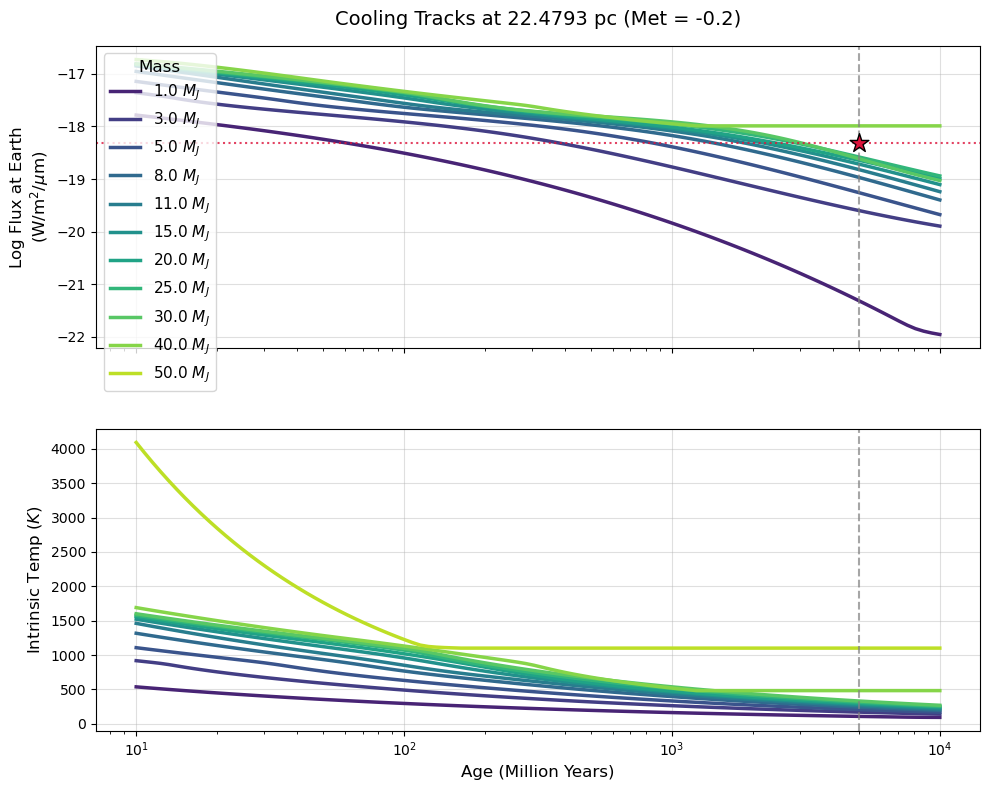

In [5]:
# --- RUN THIS ENTIRE BLOCK IN ONE JUPYTER CELL ---
%matplotlib inline

import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Ensure Python can find the cooltrack modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor

# ==========================================
# 0. PHYSICAL CONSTANTS & HELPER
# ==========================================
RJ_TO_M = 7.1492e7   # 1 Jupiter Radius in meters
PC_TO_M = 3.0857e16  # 1 Parsec in meters

def scale_to_earth_flux(surf_flux_dex, radius_rj, distance_pc):
    """Scales model surface flux to observed flux at Earth via (R/d)^2"""
    radius_m = radius_rj * RJ_TO_M
    distance_m = distance_pc * PC_TO_M
    geometric_scaling_dex = 2.0 * np.log10(radius_m / distance_m)
    return surf_flux_dex + geometric_scaling_dex

# ==========================================
# 1. SETUP THE SYSTEM & ORACLE
# ==========================================
print("Booting up CoolTrack Oracle...")
oracle = CoolTrackPredictor(
    dat_filepath="../data/cooltrack_coefficients.dat", 
    age_data_path="../data/age_data"
)

# --- SYSTEM PARAMETERS (From your FITS Header) ---
SYSTEM_AGE_YR = 5000e6     # 5000 Myr (5 Gyr)
SYSTEM_DIST_PC = 22.4793   # Parsecs
SYSTEM_MET = -0.2          # Metallicity
OBSERVED_BAND = 'JWST/MIRI.F1500W' # Based on your 15um conversion

# --- YOUR EXTRACTED OBSERVATION ---
# Replace this with the actual extracted flux value of your target/limit
EXTRACTED_FLUX_W_M2_UM = 1.3e-18 
TARGET_LOG_FLUX = np.log10(np.max(limit_w_m2_um))

# Fixed parameters for all planets in this specific system
base_params = {
    'T_irr': 0.0,           # Assuming self-luminous companion (no strong irradiation)
    'Met': 0,               # Linked to host star
    'core': 10.0, 
    'f_sed_refractory': 6.0, 
    'f_sed_volatile': 6.0, 
    'kzz': 8.0
}

# ==========================================
# 2. DEFINE THE TARGET GRID
# ==========================================
# List of masses you want to overplot
masses_to_plot = [1.0, 3.0, 5.0, 8.0, 11.0, 15.0, 20.0, 25.0, 30.0, 40.0, 50.0]

# Create an array of 100 ages spaced logarithmically from 10 Myr to 10 Gyr
ages_yr = np.logspace(7, 10, 100)

# ==========================================
# 3. EVALUATE & PLOT THE RESULTS
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Generate a nice color gradient based on the number of masses we are plotting
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(masses_to_plot)))

print(f"Evaluating {len(masses_to_plot)} evolutionary tracks (Scaled to {SYSTEM_DIST_PC} pc)...")

for i, target_mass in enumerate(masses_to_plot):
    planet_params = base_params.copy()
    planet_params['mass_Mj'] = target_mass
    
    obs_band_flux = []
    t_int = []
    
    # Evaluate the track across all ages
    for age in ages_yr:
        results = oracle.predict(target_planet=planet_params, target_age_yr=age, n_draws=0)
        
        # Pull Surface Flux and Radius
        surf_flux = results.get(f'log_{OBSERVED_BAND}', np.nan)
        radius = results.get('Req_Rj', np.nan)
        
        # Scale Total Flux to Earth Observer
        if not np.isnan(surf_flux) and not np.isnan(radius) and radius > 0:
            earth_flux = scale_to_earth_flux(surf_flux, radius, SYSTEM_DIST_PC)
            obs_band_flux.append(earth_flux)
        else:
            obs_band_flux.append(np.nan)
            
        t_int.append(results.get('T_int', np.nan))
        
    # Plot this mass on the top panel (Photometry)
    ax1.plot(ages_yr / 1e6, obs_band_flux, label=f"{target_mass} $M_J$", color=colors[i], lw=2.5)
    
    # Plot this mass on the bottom panel (Temperature)
    ax2.plot(ages_yr / 1e6, t_int, color=colors[i], lw=2.5)

# --- Format Top Panel (Photometry) ---
ax1.set_ylabel(f'Log Flux at Earth\n(W/m$^2$/$\mu$m)', fontsize=12)
ax1.set_title(f'Cooling Tracks at {SYSTEM_DIST_PC} pc (Met = {SYSTEM_MET})', fontsize=14, pad=15)
ax1.legend(loc='upper left', fontsize=11, title="Mass", title_fontsize=12)
ax1.grid(True, alpha=0.4)

# --- OVERPLOT THE REAL OBSERVATION ---
# Plot a vertical line for the System Age
ax1.axvline(x=SYSTEM_AGE_YR / 1e6, color='gray', linestyle='--', alpha=0.7, label='System Age (5 Gyr)')

# Plot a horizontal line for the Target Flux Detection Limit
ax1.axhline(y=TARGET_LOG_FLUX, color='crimson', linestyle=':', alpha=0.8, label='Observed Flux')

# Plot the exact Observation Point (Intersection)
ax1.scatter(SYSTEM_AGE_YR / 1e6, TARGET_LOG_FLUX, color='crimson', marker='*', s=200, zorder=5, edgecolor='black')

# --- Format Bottom Panel (Temperature) ---
ax2.set_xlabel('Age (Million Years)', fontsize=12)
ax2.set_ylabel('Intrinsic Temp ($K$)', fontsize=12)
ax2.set_xscale('log') 
ax2.grid(True, alpha=0.4)

ax2.axvline(x=SYSTEM_AGE_YR / 1e6, color='gray', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Loading observation data...
--> Loading real FITS data...
--> Target Age: 5000.0 Myr | Target Dist: 22.4793 pc

Booting Oracle Predictor...


2026-05-09 11:10:13,968 - INFO - Loaded initial condition interpolators from 8 files.


Calibrating Inverter for Dist: 22.4793 pc | Age: 5000.0 Myr
Calibration complete in 16.3s.

Executing Inversions...
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Processed 100 evaluations in 1.59s.
--> Scalar Test: 1.2e-16 W/m^2/um  ->  25.01 ± 0.00 M_J
Processed 400 evaluations in 0.01s.
--> 1D Profile Test complete. Processed 4 points.
--> Processing full 2D image (250x250)...
Processed 6250000 evaluations in 7.85s.


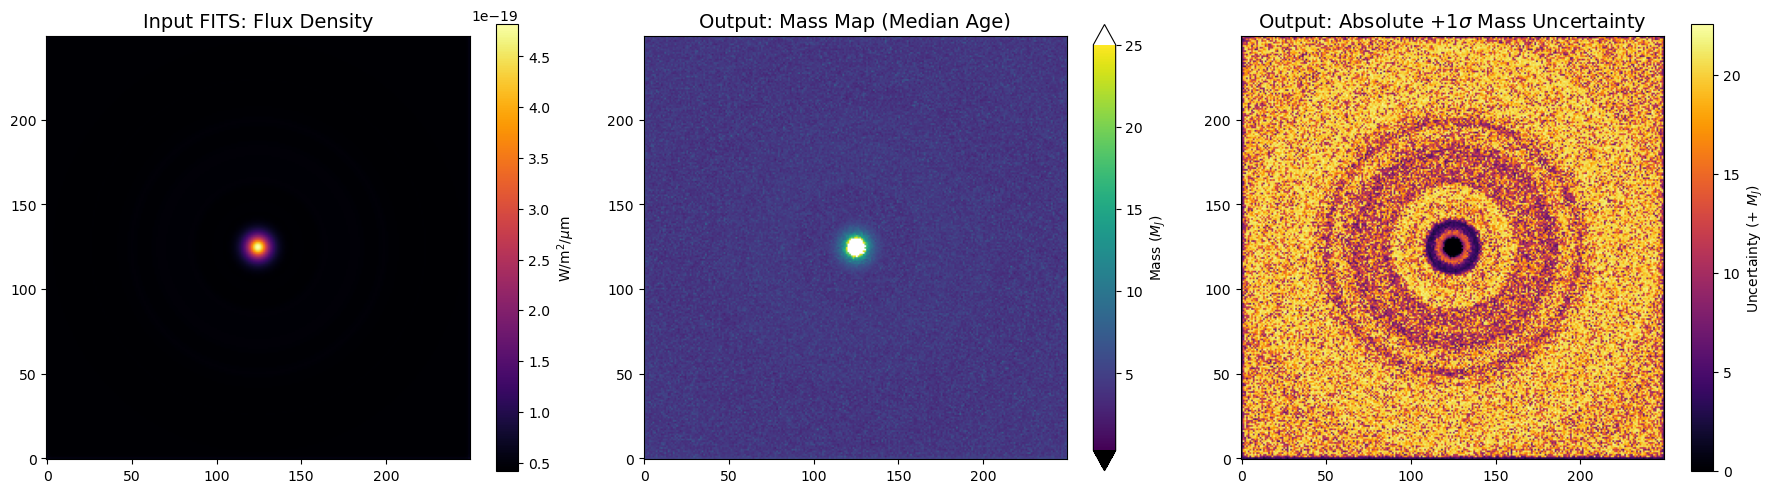

In [4]:
# ==============================================================================
# HETEROSCEDASTIC MASS INVERSION PIPELINE
# ==============================================================================
%matplotlib inline

import os
import sys
import time
import copy
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Ensure Python can find the cooltrack modules
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from cooltrack.predictor import CoolTrackPredictor
from cooltrack.mass_mapper import DoubleShotMassInverter

# ==========================================
# 1. READ & CONVERT THE OBSERVATION
# ==========================================
print("Loading observation data...")
FITS_FILE = "../data/detlim_mjup_l-231-32_obs-20_sub-sub256_date-2024-02-10_filter-f1500w_pid-03730_dither-none_uid-V03730020001P0000000003101d0o20_merged-cal_nobkg.fits"

if not os.path.exists(FITS_FILE):
    print("--> FITS not found. Generating mock 250x250 observation...")
    limit_jy = np.linspace(1e-5, 5e-5, 250) + np.random.normal(0, 1e-6, (250, 250))
    # Add a mock "bright source" detection limit spike in the center
    limit_jy += 1e-4 * np.exp(-((np.mgrid[0:250, 0:250][1] - 125)**2 + (np.mgrid[0:250, 0:250][0] - 125)**2) / 20.0)
    
    SYSTEM_AGE_YR = 5000e6
    SYSTEM_DIST_PC = 22.4793
    SYSTEM_MET = -0.2
else:
    print("--> Loading real FITS data...")
    with fits.open(FITS_FILE) as hdul:
        limit_jy = hdul[1].data
        hdr = hdul[0].header
        SYSTEM_AGE_YR = float(hdr['AGE_MYR']) * 1e6
        SYSTEM_DIST_PC = float(hdr['DISTANCE_PC'])
        SYSTEM_MET = float(hdr['MET_DEX'])

# Unit Conversion (Jy -> W/m^2/um)
c = 2.9979e8  
wavelength_m = 15e-6  
limit_w_m2_um = limit_jy * 1e-26 * (c / (wavelength_m**2)) * 1e-6

print(f"--> Target Age: {SYSTEM_AGE_YR/1e6:.1f} Myr | Target Dist: {SYSTEM_DIST_PC} pc\n")

# ==========================================
# 2. SETUP ORACLE & INVERTER
# ==========================================
print("Booting Oracle Predictor...")
oracle = CoolTrackPredictor("../data/cooltrack_coefficients.dat", "../data/age_data")

FIXED_PARAMS = {
    'T_irr': 0.0, 'Met': SYSTEM_MET, 'core': 10.0, 
    'kzz': 8.0, 'f_sed_refractory': 6.0, 'f_sed_volatile': 6.0
}
OBSERVED_BAND = 'JWST/MIRI.F1500W'  
AGE_ERROR_YR = SYSTEM_AGE_YR * 0.10 

# Initialize the modular inverter
inverter = DoubleShotMassInverter(
    oracle=oracle,
    distance_pc=SYSTEM_DIST_PC,
    system_age_yr=SYSTEM_AGE_YR,
    observed_band=OBSERVED_BAND,
    fixed_params=FIXED_PARAMS,
    min_mass=0.3,
    max_mass=25.0
)

# ==========================================
# 3. RUN INVERSIONS (SCALAR, 1D, 2D)
# ==========================================
print("\nExecuting Inversions...")

# Use Case A: Single Pixel Evaluation
mass_scalar, err_scalar = inverter.get_mass(flux_w_m2_um=1.2e-16, age_err_yr=AGE_ERROR_YR)
print(f"--> Scalar Test: 1.2e-16 W/m^2/um  ->  {mass_scalar:.2f} ± {err_scalar:.2f} M_J")

# Use Case B: Radial Profile (1D Array)
flux_profile = np.array([1e-15, 8e-16, 4e-16, 1e-16])
masses_1d, errs_1d = inverter.get_mass(flux_w_m2_um=flux_profile, age_err_yr=AGE_ERROR_YR)
print(f"--> 1D Profile Test complete. Processed {len(flux_profile)} points.")

# Use Case C: Full 2D Detection Map
print(f"--> Processing full 2D image ({limit_w_m2_um.shape[0]}x{limit_w_m2_um.shape[1]})...")
mass_map, err_map = inverter.get_mass(flux_w_m2_um=limit_w_m2_um, age_err_yr=AGE_ERROR_YR, n_draws=100)

# ==========================================
# 4. VISUALIZATION
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Input Flux
im0 = axes[0].imshow(limit_w_m2_um, cmap='inferno', origin='lower')
axes[0].set_title("Input FITS: Flux Density", fontsize=14)
plt.colorbar(im0, ax=axes[0], label='W/m$^2$/$\mu$m')

# Panel 2: Mass Limit Map
cmap_mass = copy.copy(plt.cm.viridis)
cmap_mass.set_under('black')   
cmap_mass.set_over('white')    
cmap_mass.set_bad('red')       

im1 = axes[1].imshow(mass_map, cmap=cmap_mass, origin='lower', 
                     vmin=inverter.actual_min_mass, vmax=inverter.actual_max_mass)
axes[1].set_title("Output: Mass Map (Median Age)", fontsize=14)
plt.colorbar(im1, ax=axes[1], label='Mass ($M_J$)', extend='both')

# Panel 3: Uncertainty Map
cmap_err = copy.copy(plt.cm.inferno)
cmap_err.set_bad('black') 
im2 = axes[2].imshow(err_map, cmap=cmap_err, origin='lower', vmin=0.0)
axes[2].set_title("Output: Absolute +1$\sigma$ Mass Uncertainty", fontsize=14)
plt.colorbar(im2, ax=axes[2], label='Uncertainty (+ $M_J$)')

plt.tight_layout()
plt.show()